Kmeans: Yara + Dennis
Yara: NDAVI + coastal blue/green

INITIALIZE LIBRARIES

In [1]:
# Import packages
import matplotlib.pyplot as plt
import osgeo
from os.path import join as pjoin
import pandas as pd
import numpy as np
import xarray as xr
import xrspatial as xrs
import rioxarray

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
import seaborn as sns
import datashader as ds

import pystac
from pystac_client import Client
import planetary_computer
import requests
import stackstac

import rich.table
import dask.diagnostics

path = os.getcwd()
parent = os.sep.join(path.split(os.sep)[:-1])

In [2]:
import os
import glob
import pandas as pd
import xarray as xr
import rioxarray

repo_dir = r"C:/Users/yaroc/OneDrive/Документы/GitHub/RemoteSensing_CoralReefs"

pattern1 = os.path.join(repo_dir, "data", "PSScene", "**", "*_3B_AnalyticMS_SR_8b_clip_philip.tif")
pattern2 = os.path.join(repo_dir, "data", "PSScene", "**", "*_3B_AnalyticMS_SR_8b_clip_tricia.tif")

files = sorted(glob.glob(pattern1, recursive=True) + glob.glob(pattern2, recursive=True))

dates = [pd.Timestamp(os.path.basename(f)[:8]) for f in files]

arrays = []
for f, date in zip(files, dates):
    da = rioxarray.open_rasterio(
        f,
        chunks={"band": 1, "x": 512, "y": 512}
    )
    da = da.assign_coords(time=date)
    arrays.append(da)

stack = xr.concat(arrays, dim="time").sortby("time")

print(stack)

C:\Windows\Temp\ipykernel_25044\143571173.py:25: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  stack = xr.concat(arrays, dim="time").sortby("time")
C:\Windows\Temp\ipykernel_25044\143571173.py:25: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  stack = xr.concat(arrays, dim="time").sortby("time")


<xarray.DataArray (time: 70, band: 8, y: 1237, x: 2030)> Size: 6GB
dask.array<getitem, shape=(70, 8, 1237, 2030), dtype=float32, chunksize=(1, 1, 165, 351), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 560B 2022-01-08 2022-01-17 ... 2025-12-06
  * band         (band) int32 32B 1 2 3 4 5 6 7 8
  * y            (y) float64 10kB 7.399e+06 7.399e+06 ... 7.403e+06 7.403e+06
  * x            (x) float64 16kB 4.019e+05 4.019e+05 ... 4.08e+05 4.08e+05
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:             Area
    TIFFTAG_DATETIME:          2022:01:08 23:09:32
    TIFFTAG_IMAGEDESCRIPTION:  {"atmospheric_correction": {"aerosol_model": "...
    _FillValue:                0
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 ('coastal_blue', 'blue', 'green_i', 'green', '...


In [ ]:
# Note: used fillna because many tiles might not have blue and/or green. 
# Might be better to omit these as many zero's might dampen the signal

# Band 0: Coastal Blue
# Band 1: Blue
# Band 2: Green
# Band 3: Red
# Band 4: Yellow
# Band 5: Red Edge
# Band 6: NIR
# Band 7: NIR2

from collections import defaultdict

indexes_map = defaultdict(list)
for i, stamp in enumerate(stack.time):
    indexes_map["Date"].append(str(stamp.values).split("T")[0])

    # Defining different bands
    coastal_blue = stack[i][0] 
    blue = stack[i][1]
    green = stack[i][2]
    red = stack[i][3]
    visible = (blue + green + red) / 3      #for nbrci index
    brightness = np.mean(((blue + green + red) / 3).fillna(0).values)   #for brighness index
    nir = stack[i][6]

    # Indices
    blue_green = np.mean((coastal_blue / green).fillna(0).values)          # index of blue-green ratio
    brightness = np.mean(((blue + green + red) / 3).fillna(0).values)       # index of brighness
    nbrci = np.mean(((visible - nir) / (visible + nir)).fillna(0).values)   #index of nbrci
    ndavi = np.mean(((nir - visible) / (nir + visible)).fillna(0).values)      #index of NDAVI

    # Adding to map
    indexes_map["blue_green"].append(blue_green)
    indexes_map["NDAVI"].append(ndavi)
    indexes_map["brightness"].append(brightness)
    indexes_map["nbrci"].append(nbrci)
    #check out next cell with different load of indices

c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_a

KeyboardInterrupt: 

c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\yaroc\anaconda3\envs\geospatial\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_a

In [ ]:
#this one also loads quite long, took 82 min and loaded nth eventually
import numpy as np
import xarray as xr
from collections import defaultdict

indexes_map = defaultdict(list)

for i, stamp in enumerate(stack.time):
    indexes_map["Date"].append(str(stamp.values).split("T")[0])

    # Bands
    coastal_blue = stack[i][0]
    blue = stack[i][1]
    green = stack[i][2]
    red = stack[i][3]
    nir = stack[i][6]

    # Mean visible reflectance
    visible = (blue + green + red) / 3

    # Safe division helper
    def safe_divide(num, den):
        return xr.where((den != 0) & np.isfinite(den) & np.isfinite(num), num / den, np.nan)

    # Pixelwise indices
    blue_green_px = safe_divide(coastal_blue, green)
    nbrci_px = safe_divide(visible - nir, visible + nir)
    ndavi_px = safe_divide(nir - visible, nir + visible)

    # Brightness does not need division
    brightness_px = (blue + green + red) / 3
    brightness_px = brightness_px.where(np.isfinite(brightness_px), np.nan)

    # Aggregate means, skipping NaNs
    blue_green = float(blue_green_px.mean(skipna=True).values)
    brightness = float(brightness_px.mean(skipna=True).values)
    nbrci = float(nbrci_px.mean(skipna=True).values)
    ndavi = float(ndavi_px.mean(skipna=True).values)

    # Store
    indexes_map["blue_green"].append(blue_green)
    indexes_map["NDAVI"].append(ndavi)
    indexes_map["brightness"].append(brightness)
    indexes_map["nbrci"].append(nbrci)

KeyboardInterrupt: 

In [ ]:
df_indexes = pd.DataFrame(indexes_map)

In [ ]:
df_indexes.head()

,Date,blue_green,NDAVI,brightness,nbrci
0,2022-01-08,0.456528,-0.216416,998.682373,0.216416
1,2022-01-17,0.177390,-0.137086,282.024750,0.137086
2,2022-01-17,0.521855,-0.491232,929.946594,0.491232
3,2022-02-08,0.503119,-0.301956,1049.614014,0.301956
4,2022-02-26,0.513632,-0.339674,919.668945,0.339674


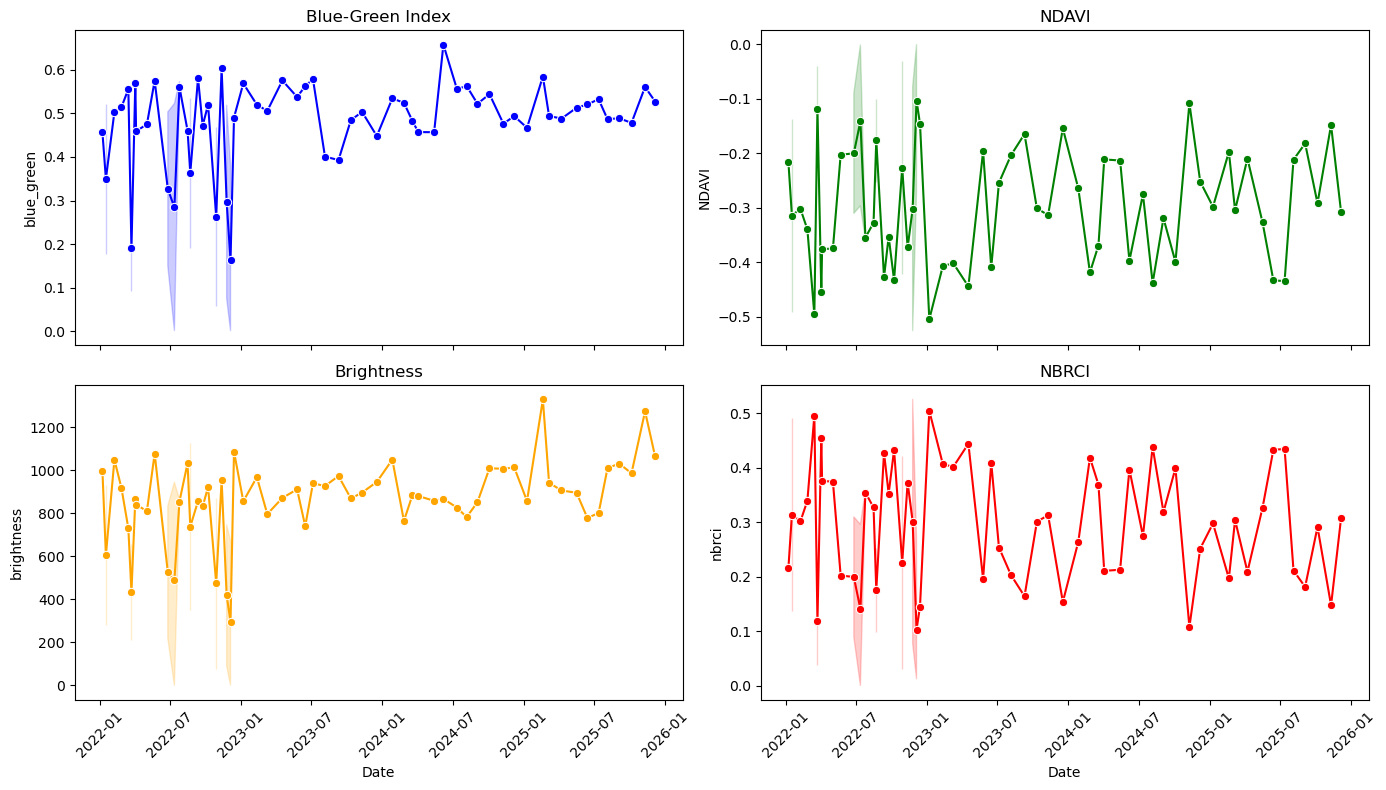

In [ ]:
df_indexes["Date"] = pd.to_datetime(df_indexes["Date"])
df_indexes = df_indexes.sort_values("Date")

index_cols = ["blue_green", "NDAVI", "brightness", "nbrci"]

colors = {
    "blue_green": "blue",
    "NDAVI": "green",
    "brightness": "orange",
    "nbrci": "red"
}

titles = {
    "blue_green": "Blue-Green Index",
    "NDAVI": "NDAVI",
    "brightness": "Brightness",
    "nbrci": "NBRCI"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes = axes.flatten()

for i, col in enumerate(index_cols):
    sns.lineplot(
        data=df_indexes,
        x="Date",
        y=col,
        marker="o",
        color=colors[col],
        ax=axes[i]
    )
    
    axes[i].set_title(titles[col])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()